# A vs B/C Classifier

In [1]:
#Import libraries
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.utils.class_weight import compute_class_weight

In [2]:
#Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Optional, can make training slower
# tf.config.experimental.enable_op_determinism()

## Load tensors

In [4]:
#Load tensors
TENSOR_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_tensors")

X_torch = torch.load(TENSOR_DIR / "X_features.pt")
y_torch = torch.load(TENSOR_DIR / "y_labels.pt")
fold_torch = torch.load(TENSOR_DIR / "folds.pt")

X_tf = tf.convert_to_tensor(X_torch.cpu().numpy(), dtype=tf.float32)
y_tf = tf.convert_to_tensor(y_torch.cpu().numpy(), dtype=tf.int64)
fold_tf = tf.convert_to_tensor(fold_torch.cpu().numpy(), dtype=tf.int64)

print("X:", X_tf.shape)
print("y:", y_tf.shape)
print("folds:", fold_tf.shape)

C:\Users\omarl\AppData\Local\Temp\ipykernel_22652\1690075706.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_torch = torch.load(TENSOR_DIR / "X_features.pt")
C:\Users\

X: (20931, 86, 65)
y: (20931,)
folds: (20931,)


In [5]:
#Keep only labeled data (y != -1)
labeled_mask = y_tf != -1

X_labeled = tf.boolean_mask(X_tf, labeled_mask)
y_labeled = tf.boolean_mask(y_tf, labeled_mask)
fold_labeled = tf.boolean_mask(fold_tf, labeled_mask)

print("X labeled:", X_labeled.shape)
print("y labeled:", y_labeled.shape)
print("fold labeled:", fold_labeled.shape)

print(pd.Series(y_labeled.numpy()).value_counts().sort_index())

X labeled: (11899, 86, 65)
y labeled: (11899,)
fold labeled: (11899,)
0    6406
1    3349
2    2144
Name: count, dtype: int64


In [6]:
#Mapping
label_names_3class = {
    0: "SEG_A",
    1: "SEG_B",
    2: "SEG_C"
}

target_names_3class = ["SEG_A", "SEG_B", "SEG_C"]

## Fold split

In [7]:
#Fold split
test_fold = 3
val_fold = 4

train_mask = (fold_labeled != test_fold) & (fold_labeled != val_fold)
val_mask = fold_labeled == val_fold
test_mask = fold_labeled == test_fold

X_train_all = tf.boolean_mask(X_labeled, train_mask)
y_train_all = tf.boolean_mask(y_labeled, train_mask)

X_val_all = tf.boolean_mask(X_labeled, val_mask)
y_val_all = tf.boolean_mask(y_labeled, val_mask)

X_test_all = tf.boolean_mask(X_labeled, test_mask)
y_test_all = tf.boolean_mask(y_labeled, test_mask)

print("Train:", X_train_all.shape, y_train_all.shape)
print("Val:", X_val_all.shape, y_val_all.shape)
print("Test:", X_test_all.shape, y_test_all.shape)

Train: (7140, 86, 65) (7140,)
Val: (2379, 86, 65) (2379,)
Test: (2380, 86, 65) (2380,)


## Binary labeling (A vs B/C)

In [8]:
#Binary labeling (A vs B/C)
y_train_binary = tf.cast(y_train_all != 0, tf.int64)
y_val_binary = tf.cast(y_val_all != 0, tf.int64)
y_test_binary = tf.cast(y_test_all != 0, tf.int64)

binary_target_names = ["SEG_A", "SEG_BC"]

print("Train binary distribution:")
print(pd.Series(y_train_binary.numpy()).value_counts().sort_index())

print("Validation binary distribution:")
print(pd.Series(y_val_binary.numpy()).value_counts().sort_index())

print("Test binary distribution:")
print(pd.Series(y_test_binary.numpy()).value_counts().sort_index())

Train binary distribution:
0    3844
1    3296
Name: count, dtype: int64
Validation binary distribution:
0    1281
1    1098
Name: count, dtype: int64
Test binary distribution:
0    1281
1    1099
Name: count, dtype: int64


In [9]:
# Compute class weights for binary classification
classes_binary = np.unique(y_train_binary.numpy())

weights_binary = compute_class_weight(
    class_weight="balanced",
    classes=classes_binary,
    y=y_train_binary.numpy()
)

class_weight_binary = dict(zip(classes_binary, weights_binary))
class_weight_binary

{0: 0.9287200832466181, 1: 1.083131067961165}

## Model functions

In [10]:
#CNN model function
n_weeks = X_train_all.shape[1]
n_features = X_train_all.shape[2]

def build_cnn_classifier(
    n_weeks,
    n_features,
    n_classes,
    learning_rate=3e-4,
    dropout_config=(0.3, 0.3, 0.35, 0.4),
    l2_reg=1e-4
):
    d1, d2, d3, d_dense = dropout_config
    
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    
    model = models.Sequential([
        layers.Input(shape=(n_weeks, n_features)),

        layers.BatchNormalization(),

        layers.Conv1D(
            64, 3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d1),

        layers.Conv1D(
            64, 5,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d2),

        layers.Conv1D(
            128, 3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d3),

        layers.GlobalAveragePooling1D(),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.Dropout(d_dense),

        layers.Dense(n_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

## Binary model training

In [11]:
# Binary model training
binary_model = build_cnn_classifier(
    n_weeks=n_weeks,
    n_features=n_features,
    n_classes=2,
    learning_rate=3e-4,
    dropout_config=(0.3, 0.3, 0.35, 0.4)
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history_binary = binary_model.fit(
    X_train_all,
    y_train_binary,
    validation_data=(X_val_all, y_val_binary),
    epochs=60,
    batch_size=128,
    class_weight=class_weight_binary,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6636 - loss: 0.6432 - val_accuracy: 0.7394 - val_loss: 0.6309 - learning_rate: 3.0000e-04
Epoch 2/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7345 - loss: 0.5673 - val_accuracy: 0.7461 - val_loss: 0.5918 - learning_rate: 3.0000e-04
Epoch 3/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7483 - loss: 0.5480 - val_accuracy: 0.7499 - val_loss: 0.5633 - learning_rate: 3.0000e-04
Epoch 4/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7541 - loss: 0.5387 - val_accuracy: 0.7524 - val_loss: 0.5451 - learning_rate: 3.0000e-04
Epoch 5/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7591 - loss: 0.5322 - val_accuracy: 0.7579 - val_loss: 0.5304 - learning_rate: 3.0000e-04
Epoch 6/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7609 - loss: 0.5252 - val_accuracy: 0.7612 - val_loss: 0.5250 - learning_rate: 3.0000e-04
Epoch 7/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7703

In [ ]:
#Evaluation
proba_binary_test = binary_model.predict(X_test_all)
y_pred_binary = np.argmax(proba_binary_test, axis=1)
y_true_binary = y_test_binary.numpy()

print("Binary Accuracy:", accuracy_score(y_true_binary, y_pred_binary))
print("Binary Macro F1:", f1_score(y_true_binary, y_pred_binary, average="macro"))
print("Binary Weighted F1:", f1_score(y_true_binary, y_pred_binary, average="weighted"))

print(classification_report(
    y_true_binary,
    y_pred_binary,
    target_names=binary_target_names
))

try:
    print("Binary ROC AUC:", roc_auc_score(y_true_binary, proba_binary_test[:, 1]))
except Exception as e:
    print("ROC AUC could not be computed:", e)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Binary Accuracy: 0.7542016806722689
Binary Macro F1: 0.7511161163174195
Binary Weighted F1: 0.7532352586290519
              precision    recall  f1-score   support

       SEG_A       0.76      0.80      0.78      1281
      SEG_BC       0.75      0.70      0.72      1099

    accuracy                           0.75      2380
   macro avg       0.75      0.75      0.75      2380
weighted avg       0.75      0.75      0.75      2380

Binary ROC AUC: 0.8298573893376918


## B vs C Model

In [13]:
# B vs C split
bc_train_mask = y_train_all != 0
bc_val_mask = y_val_all != 0
bc_test_mask = y_test_all != 0

X_train_bc = tf.boolean_mask(X_train_all, bc_train_mask)
X_val_bc = tf.boolean_mask(X_val_all, bc_val_mask)
X_test_bc = tf.boolean_mask(X_test_all, bc_test_mask)

y_train_bc_original = tf.boolean_mask(y_train_all, bc_train_mask)
y_val_bc_original = tf.boolean_mask(y_val_all, bc_val_mask)
y_test_bc_original = tf.boolean_mask(y_test_all, bc_test_mask)

# Re-map:
# original 1 SEG_B -> 0
# original 2 SEG_C -> 1
y_train_bc = y_train_bc_original - 1
y_val_bc = y_val_bc_original - 1
y_test_bc = y_test_bc_original - 1

bc_target_names = ["SEG_B", "SEG_C"]

print("B/C train:", X_train_bc.shape, y_train_bc.shape)
print("B/C val:", X_val_bc.shape, y_val_bc.shape)
print("B/C test:", X_test_bc.shape, y_test_bc.shape)

print("B/C train distribution:")
print(pd.Series(y_train_bc.numpy()).value_counts().sort_index())

B/C train: (3296, 86, 65) (3296,)
B/C val: (1098, 86, 65) (1098,)
B/C test: (1099, 86, 65) (1099,)
B/C train distribution:
0    2009
1    1287
Name: count, dtype: int64


In [14]:
# Compute class weights for B vs C classification
classes_bc = np.unique(y_train_bc.numpy())

weights_bc = compute_class_weight(
    class_weight="balanced",
    classes=classes_bc,
    y=y_train_bc.numpy()
)

class_weight_bc = dict(zip(classes_bc, weights_bc))
class_weight_bc

{0: 0.8203086112493778, 1: 1.2804972804972805}

In [15]:
# B vs C model training
bc_model = build_cnn_classifier(
    n_weeks=n_weeks,
    n_features=n_features,
    n_classes=2,
    learning_rate=3e-4,
    dropout_config=(0.3, 0.3, 0.35, 0.4)
)

early_stop_bc = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr_bc = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history_bc = bc_model.fit(
    X_train_bc,
    y_train_bc,
    validation_data=(X_val_bc, y_val_bc),
    epochs=60,
    batch_size=128,
    class_weight=class_weight_bc,
    callbacks=[early_stop_bc, reduce_lr_bc],
    verbose=1
)

Epoch 1/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5421 - loss: 0.7397 - val_accuracy: 0.5373 - val_loss: 0.7167 - learning_rate: 3.0000e-04
Epoch 2/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5823 - loss: 0.7055 - val_accuracy: 0.5601 - val_loss: 0.7087 - learning_rate: 3.0000e-04
Epoch 3/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6263 - loss: 0.6799 - val_accuracy: 0.5719 - val_loss: 0.7053 - learning_rate: 3.0000e-04
Epoch 4/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6330 - loss: 0.6767 - val_accuracy: 0.5792 - val_loss: 0.7012 - learning_rate: 3.0000e-04
Epoch 5/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6317 - loss: 0.6641 - val_accuracy: 0.5865 - val_loss: 0.6975 - learning_rate: 3.0000e-04
Epoch 6/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6265 - loss: 0.6685 - val_accuracy: 0.5956 - val_loss: 0.6949 - learning_rate: 3.0000e-04
Epoch 7/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6402 

In [16]:
# Evaluation
proba_bc_test = bc_model.predict(X_test_bc)
y_pred_bc = np.argmax(proba_bc_test, axis=1)
y_true_bc = y_test_bc.numpy()

print("B/C Accuracy:", accuracy_score(y_true_bc, y_pred_bc))
print("B/C Macro F1:", f1_score(y_true_bc, y_pred_bc, average="macro"))
print("B/C Weighted F1:", f1_score(y_true_bc, y_pred_bc, average="weighted"))

print(classification_report(
    y_true_bc,
    y_pred_bc,
    target_names=bc_target_names
))

try:
    print("B/C ROC AUC:", roc_auc_score(y_true_bc, proba_bc_test[:, 1]))
except Exception as e:
    print("ROC AUC could not be computed:", e)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
B/C Accuracy: 0.6442220200181984
B/C Macro F1: 0.6423267501858247
B/C Weighted F1: 0.6480362505558503
              precision    recall  f1-score   support

       SEG_B       0.77      0.59      0.67       670
       SEG_C       0.53      0.73      0.62       429

    accuracy                           0.64      1099
   macro avg       0.65      0.66      0.64      1099
weighted avg       0.68      0.64      0.65      1099

B/C ROC AUC: 0.7108130675294854


In [17]:
# %%
# Binary probabilities over all test doctors
proba_binary_all = binary_model.predict(X_test_all)

# B/C probabilities over all test doctors
# Important: we can run the B/C model on all test doctors,
# even though it was trained only on B/C doctors.
proba_bc_all = bc_model.predict(X_test_all)

# Binary model:
# class 0 = SEG_A
# class 1 = SEG_BC
p_A = proba_binary_all[:, 0]
p_BC = proba_binary_all[:, 1]

# B/C model:
# class 0 = SEG_B
# class 1 = SEG_C
p_B_given_BC = proba_bc_all[:, 0]
p_C_given_BC = proba_bc_all[:, 1]

# Final hierarchical probabilities
p_B = p_BC * p_B_given_BC
p_C = p_BC * p_C_given_BC

proba_hierarchical = np.vstack([p_A, p_B, p_C]).T

# Optional sanity check
print(proba_hierarchical[:5])
print("Row sums:", proba_hierarchical.sum(axis=1)[:5])

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[0.7487475  0.1295438  0.12170873]
 [0.415803   0.21954185 0.36465523]
 [0.69918096 0.12272765 0.17809138]
 [0.16547212 0.23016803 0.60435987]
 [0.88338685 0.05532844 0.06128477]]
Row sums: [1.        1.0000001 1.        1.        1.       ]


In [18]:
# %%
y_pred_hierarchical = np.argmax(proba_hierarchical, axis=1)
y_true_3class = y_test_all.numpy()

print("Hierarchical Accuracy:", accuracy_score(y_true_3class, y_pred_hierarchical))
print("Hierarchical Macro F1:", f1_score(y_true_3class, y_pred_hierarchical, average="macro"))
print("Hierarchical Weighted F1:", f1_score(y_true_3class, y_pred_hierarchical, average="weighted"))

print(classification_report(
    y_true_3class,
    y_pred_hierarchical,
    target_names=target_names_3class
))

Hierarchical Accuracy: 0.6600840336134454
Hierarchical Macro F1: 0.5676949521696426
Hierarchical Weighted F1: 0.6419038325299645
              precision    recall  f1-score   support

       SEG_A       0.73      0.88      0.80      1281
       SEG_B       0.64      0.38      0.47       670
       SEG_C       0.42      0.43      0.43       429

    accuracy                           0.66      2380
   macro avg       0.60      0.56      0.57      2380
weighted avg       0.65      0.66      0.64      2380



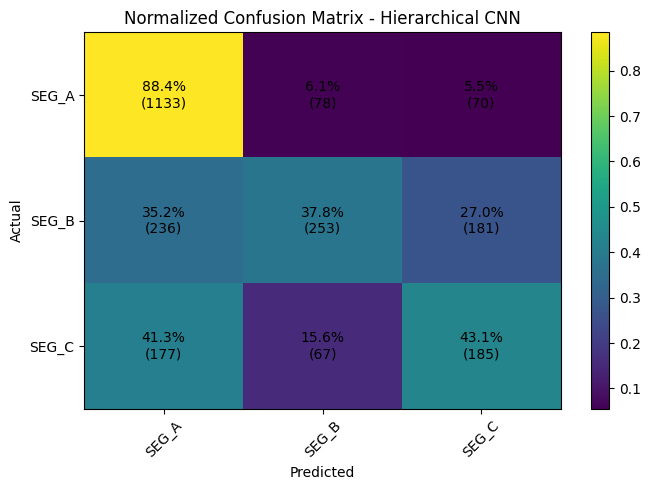

In [19]:
# %%
def plot_confusion_matrix_with_percentages(
    y_true,
    y_pred,
    target_names,
    normalize=True,
    title="Confusion Matrix"
):
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm_display = cm / cm.sum(axis=1, keepdims=True)
    else:
        cm_display = cm

    plt.figure(figsize=(7, 5))
    plt.imshow(cm_display, aspect="auto")
    plt.colorbar()

    plt.xticks(range(len(target_names)), target_names, rotation=45)
    plt.yticks(range(len(target_names)), target_names)

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                text = f"{cm_display[i, j]*100:.1f}%\n({cm[i, j]})"
            else:
                text = f"{cm[i, j]}"
            
            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

plot_confusion_matrix_with_percentages(
    y_true=y_true_3class,
    y_pred=y_pred_hierarchical,
    target_names=target_names_3class,
    normalize=True,
    title="Normalized Confusion Matrix - Hierarchical CNN"
)

In [20]:
# %%
hierarchical_predictions_df = pd.DataFrame({
    "true_label_encoded": y_true_3class,
    "true_label": [target_names_3class[i] for i in y_true_3class],
    "pred_label_encoded": y_pred_hierarchical,
    "pred_label": [target_names_3class[i] for i in y_pred_hierarchical],
    "prob_SEG_A": proba_hierarchical[:, 0],
    "prob_SEG_B": proba_hierarchical[:, 1],
    "prob_SEG_C": proba_hierarchical[:, 2],
    "prob_SEG_BC": p_BC,
    "prob_B_given_BC": p_B_given_BC,
    "prob_C_given_BC": p_C_given_BC
})

hierarchical_predictions_df.head()

,true_label_encoded,true_label,pred_label_encoded,pred_label,prob_SEG_A,prob_SEG_B,prob_SEG_C,prob_SEG_BC,prob_B_given_BC,prob_C_given_BC
0,0,SEG_A,0,SEG_A,0.748748,0.129544,0.121709,0.251253,0.515592,0.484408
1,0,SEG_A,0,SEG_A,0.415803,0.219542,0.364655,0.584197,0.375801,0.624199
2,0,SEG_A,0,SEG_A,0.699181,0.122728,0.178091,0.300819,0.407978,0.592022
3,1,SEG_B,2,SEG_C,0.165472,0.230168,0.604360,0.834528,0.275806,0.724194
4,0,SEG_A,0,SEG_A,0.883387,0.055328,0.061285,0.116613,0.474461,0.525539


In [21]:
# %%
bc_uncertainty_df = hierarchical_predictions_df[
    hierarchical_predictions_df["pred_label"].isin(["SEG_B", "SEG_C"])
].copy()

bc_uncertainty_df["BC_probability_gap"] = (
    bc_uncertainty_df["prob_B_given_BC"] - bc_uncertainty_df["prob_C_given_BC"]
).abs()

bc_uncertainty_df.sort_values("BC_probability_gap").head(20)

,true_label_encoded,true_label,pred_label_encoded,pred_label,prob_SEG_A,prob_SEG_B,prob_SEG_C,prob_SEG_BC,prob_B_given_BC,prob_C_given_BC,BC_probability_gap
1052,1,SEG_B,2,SEG_C,0.025278,0.487174,0.487548,0.974721,0.499808,0.500192,0.000384
1249,1,SEG_B,1,SEG_B,0.049892,0.475294,0.474815,0.950108,0.500252,0.499748,0.000504
538,1,SEG_B,2,SEG_C,0.010689,0.494178,0.495133,0.989311,0.499517,0.500483,0.000966
1843,2,SEG_C,2,SEG_C,0.177889,0.410179,0.411932,0.822111,0.498934,0.501066,0.002131
672,1,SEG_B,1,SEG_B,0.123761,0.439532,0.436707,0.876239,0.501612,0.498388,0.003225
167,1,SEG_B,1,SEG_B,0.022531,0.490478,0.486991,0.977469,0.501783,0.498217,0.003567
1372,1,SEG_B,2,SEG_C,0.067352,0.464555,0.468094,0.932648,0.498103,0.501897,0.003795
403,2,SEG_C,1,SEG_B,0.241062,0.381097,0.377841,0.758938,0.502145,0.497855,0.004290
255,2,SEG_C,1,SEG_B,0.099433,0.452316,0.448252,0.900568,0.502256,0.497744,0.004512
2059,1,SEG_B,2,SEG_C,0.012391,0.491508,0.496101,0.987609,0.497675,0.502325,0.004651


In [22]:
# %%
bc_uncertainty_df["BC_decision_confidence"] = np.where(
    bc_uncertainty_df["BC_probability_gap"] < 0.15,
    "Low confidence B/C decision",
    "Higher confidence B/C decision"
)

bc_uncertainty_df["BC_decision_confidence"].value_counts()

BC_decision_confidence
Higher confidence B/C decision    622
Low confidence B/C decision       212
Name: count, dtype: int64

In [23]:
threshold_results_hier = []

y_true_3class = y_test_all.numpy()

for threshold_bc in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55]:
    
    # Probabilidades del primer modelo
    p_A = proba_binary_all[:, 0]
    p_BC = proba_binary_all[:, 1]
    
    # Probabilidades del segundo modelo
    p_B_given_BC = proba_bc_all[:, 0]
    p_C_given_BC = proba_bc_all[:, 1]
    
    # Inicialmente todos como SEG_A
    y_pred_h = np.zeros(len(y_true_3class), dtype=int)
    
    # Los que superan threshold pasan a B/C
    bc_mask = p_BC >= threshold_bc
    
    # Dentro de B/C, elegir B o C usando segundo modelo
    y_pred_bc_local = np.where(
        p_B_given_BC >= p_C_given_BC,
        1,  # SEG_B
        2   # SEG_C
    )
    
    y_pred_h[bc_mask] = y_pred_bc_local[bc_mask]
    
    report = classification_report(
        y_true_3class,
        y_pred_h,
        target_names=target_names_3class,
        output_dict=True
    )
    
    threshold_results_hier.append({
        "threshold_BC": threshold_bc,
        "accuracy": accuracy_score(y_true_3class, y_pred_h),
        "macro_f1": f1_score(y_true_3class, y_pred_h, average="macro"),
        "weighted_f1": f1_score(y_true_3class, y_pred_h, average="weighted"),
        "SEG_A_recall": report["SEG_A"]["recall"],
        "SEG_B_recall": report["SEG_B"]["recall"],
        "SEG_C_recall": report["SEG_C"]["recall"],
        "SEG_A_f1": report["SEG_A"]["f1-score"],
        "SEG_B_f1": report["SEG_B"]["f1-score"],
        "SEG_C_f1": report["SEG_C"]["f1-score"]
    })

threshold_results_hier_df = pd.DataFrame(threshold_results_hier)
threshold_results_hier_df

,threshold_BC,accuracy,macro_f1,weighted_f1,SEG_A_recall,SEG_B_recall,SEG_C_recall,SEG_A_f1,SEG_B_f1,SEG_C_f1
0,0.30,0.565126,0.540372,0.584452,0.567525,0.507463,0.648019,0.675651,0.497440,0.448026
1,0.35,0.598739,0.558742,0.612787,0.660422,0.482090,0.596737,0.725557,0.502724,0.447944
2,0.40,0.615966,0.564177,0.624567,0.718189,0.458209,0.557110,0.751941,0.496764,0.443825
3,0.45,0.624790,0.562446,0.627878,0.759563,0.441791,0.508159,0.765238,0.491694,0.430405
4,0.50,0.636134,0.562993,0.632255,0.804059,0.416418,0.477855,0.778828,0.483955,0.426195
5,0.55,0.641597,0.559494,0.631077,0.836066,0.391045,0.452214,0.784903,0.469534,0.424044


In [24]:
threshold_results_hier_df.sort_values(
    ["macro_f1", "SEG_C_recall", "SEG_B_recall"],
    ascending=False
)

,threshold_BC,accuracy,macro_f1,weighted_f1,SEG_A_recall,SEG_B_recall,SEG_C_recall,SEG_A_f1,SEG_B_f1,SEG_C_f1
2,0.40,0.615966,0.564177,0.624567,0.718189,0.458209,0.557110,0.751941,0.496764,0.443825
4,0.50,0.636134,0.562993,0.632255,0.804059,0.416418,0.477855,0.778828,0.483955,0.426195
3,0.45,0.624790,0.562446,0.627878,0.759563,0.441791,0.508159,0.765238,0.491694,0.430405
5,0.55,0.641597,0.559494,0.631077,0.836066,0.391045,0.452214,0.784903,0.469534,0.424044
1,0.35,0.598739,0.558742,0.612787,0.660422,0.482090,0.596737,0.725557,0.502724,0.447944
0,0.30,0.565126,0.540372,0.584452,0.567525,0.507463,0.648019,0.675651,0.497440,0.448026


In [25]:
double_threshold_results = []

y_true_3class = y_test_all.numpy()

for threshold_bc in [0.35, 0.40, 0.45, 0.50]:
    for threshold_c in [0.45, 0.50, 0.55, 0.60]:
        
        p_BC = proba_binary_all[:, 1]
        p_C_given_BC = proba_bc_all[:, 1]
        
        y_pred_h = np.zeros(len(y_true_3class), dtype=int)
        
        bc_mask = p_BC >= threshold_bc
        
        # Dentro de los que pasan a B/C:
        # si prob C >= threshold_c => SEG_C, si no => SEG_B
        y_pred_h[bc_mask] = np.where(
            p_C_given_BC[bc_mask] >= threshold_c,
            2,  # SEG_C
            1   # SEG_B
        )
        
        report = classification_report(
            y_true_3class,
            y_pred_h,
            target_names=target_names_3class,
            output_dict=True
        )
        
        double_threshold_results.append({
            "threshold_BC": threshold_bc,
            "threshold_C_given_BC": threshold_c,
            "accuracy": accuracy_score(y_true_3class, y_pred_h),
            "macro_f1": f1_score(y_true_3class, y_pred_h, average="macro"),
            "weighted_f1": f1_score(y_true_3class, y_pred_h, average="weighted"),
            "SEG_A_recall": report["SEG_A"]["recall"],
            "SEG_B_recall": report["SEG_B"]["recall"],
            "SEG_C_recall": report["SEG_C"]["recall"],
            "SEG_A_f1": report["SEG_A"]["f1-score"],
            "SEG_B_f1": report["SEG_B"]["f1-score"],
            "SEG_C_f1": report["SEG_C"]["f1-score"]
        })

double_threshold_results_df = pd.DataFrame(double_threshold_results)

double_threshold_results_df.sort_values(
    ["macro_f1", "weighted_f1", "SEG_B_recall", "SEG_C_recall"],
    ascending=False
).head(10)

,threshold_BC,threshold_C_given_BC,accuracy,macro_f1,weighted_f1,SEG_A_recall,SEG_B_recall,SEG_C_recall,SEG_A_f1,SEG_B_f1,SEG_C_f1
6,0.40,0.55,0.625630,0.573437,0.632889,0.718189,0.535821,0.489510,0.751941,0.529499,0.438871
14,0.50,0.55,0.646218,0.573159,0.641796,0.804059,0.491045,0.417249,0.778828,0.523885,0.416764
10,0.45,0.55,0.635294,0.572859,0.637242,0.759563,0.517910,0.447552,0.765238,0.528561,0.424779
7,0.40,0.60,0.627311,0.567533,0.631499,0.718189,0.604478,0.391608,0.751941,0.547297,0.403361
15,0.50,0.60,0.648739,0.567255,0.641072,0.804059,0.555224,0.331002,0.778828,0.548268,0.374670
2,0.35,0.55,0.607983,0.567235,0.620023,0.660422,0.561194,0.524476,0.725557,0.528833,0.447316
11,0.45,0.60,0.637395,0.566757,0.636028,0.759563,0.583582,0.356643,0.765238,0.549157,0.385876
5,0.40,0.50,0.615966,0.564177,0.624567,0.718189,0.458209,0.557110,0.751941,0.496764,0.443825
13,0.50,0.50,0.636134,0.562993,0.632255,0.804059,0.416418,0.477855,0.778828,0.483955,0.426195
9,0.45,0.50,0.624790,0.562446,0.627878,0.759563,0.441791,0.508159,0.765238,0.491694,0.430405


In [26]:
business_output = []

threshold_bc = 0.40
threshold_c = 0.55
uncertainty_gap = 0.15

for i in range(len(y_true_3class)):
    p_bc = proba_binary_all[i, 1]
    p_b = proba_bc_all[i, 0]
    p_c = proba_bc_all[i, 1]
    
    if p_bc < threshold_bc:
        business_output.append("SEG_A")
    else:
        gap = abs(p_b - p_c)
        
        if gap < uncertainty_gap:
            business_output.append("SEG_B/C uncertain")
        elif p_c >= threshold_c:
            business_output.append("SEG_C")
        else:
            business_output.append("SEG_B")

pd.Series(business_output).value_counts()

SEG_A                1166
SEG_C                 468
SEG_B                 420
SEG_B/C uncertain     326
Name: count, dtype: int64